# Result Analysis

This notebook loads FLEXIMOD output folders and compares the economic result by market stage.

The first table uses four stages:

- gas-only benchmark: no electricity market participation, heat supplied only by gas boiler;
- after day-ahead: DA electricity procurement plus remaining gas heat;
- after day-ahead + intraday: DA baseline plus IDC buy/sell adjustment plus remaining gas heat;
- final all enabled stages: final dispatch including aFRR energy and capacity revenue where available.

In [10]:
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from a notebook or script working directory."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find the FLEXIMOD project root.")


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "data" / "output"

available_use_cases = sorted(
    path.name
    for path in OUTPUT_ROOT.iterdir()
    if path.is_dir() and (path / "dispatch_results.csv").exists()
)

print(f"Project root: {PROJECT_ROOT}")
print("Available use cases:")
for use_case in available_use_cases:
    print(f"- {use_case}")

Project root: C:\Manish_REPO\FLEXIMOD
Available use cases:
- hybrid_ETES_DE


## Select Use Case

Change `USE_CASE` to one of the printed output folders. Set `USE_CASE = None` to analyse all available use cases together.

In [11]:
USE_CASE = "hybrid_ETES_DE"

if USE_CASE is None:
    SELECTED_SCENARIOS = None
else:
    if USE_CASE not in available_use_cases:
        raise ValueError(
            f"Unknown use case '{USE_CASE}'. Available use cases are: {available_use_cases}"
        )
    SELECTED_SCENARIOS = [USE_CASE]

print("Selected use case(s):", SELECTED_SCENARIOS or available_use_cases)

Selected use case(s): ['hybrid_ETES_DE']


## Build Stage-Wise Cost Table

This cell loads the selected output data and calculates the net cost for the gas-only benchmark, day-ahead stage, day-ahead plus intraday stage, and final all-market result.

In [12]:
def discover_scenarios(output_root: Path, selected: list[str] | None = None) -> dict[str, Path]:
    """Return scenario output folders that contain dispatch_results.csv."""
    if selected:
        scenarios = {name: output_root / name for name in selected}
    else:
        scenarios = {
            path.name: path
            for path in sorted(output_root.iterdir())
            if path.is_dir() and (path / "dispatch_results.csv").exists()
        }

    missing = [
        name for name, path in scenarios.items() if not (path / "dispatch_results.csv").exists()
    ]
    if missing:
        raise FileNotFoundError(
            "Missing dispatch_results.csv for scenario(s): " + ", ".join(missing)
        )
    if not scenarios:
        raise FileNotFoundError(f"No FLEXIMOD outputs found below {output_root}.")
    return scenarios


def load_dispatch(output_dir: Path) -> pd.DataFrame:
    """Load dispatch results and parse datetimes."""
    dispatch = pd.read_csv(output_dir / "dispatch_results.csv")
    if "datetime" in dispatch.columns:
        dispatch["datetime"] = pd.to_datetime(dispatch["datetime"])
    if "plant_name" not in dispatch.columns:
        dispatch["plant_name"] = "plant"
    return dispatch


def sum_column(frame: pd.DataFrame, column: str) -> float:
    """Return a numeric column sum, or zero if the column is missing."""
    if column not in frame.columns:
        return 0.0
    return float(pd.to_numeric(frame[column], errors="coerce").fillna(0.0).sum())


def infer_gas_boiler_efficiency(frame: pd.DataFrame, fallback: float = 0.9) -> float:
    """Infer boiler efficiency from final gas heat and gas input outputs."""
    required = {"gas_heat_MWh", "gas_input_MWh"}
    if not required.issubset(frame.columns):
        return fallback

    gas_input = pd.to_numeric(frame["gas_input_MWh"], errors="coerce")
    gas_heat = pd.to_numeric(frame["gas_heat_MWh"], errors="coerce")
    valid = gas_input > 1e-9
    if not valid.any():
        return fallback
    return float((gas_heat[valid] / gas_input[valid]).median())


def gas_cost_from_heat(frame: pd.DataFrame, heat_column: str, boiler_efficiency: float) -> float:
    """Convert useful gas heat dispatch into gas fuel cost."""
    if heat_column not in frame.columns:
        heat_column = "gas_heat_MWh"
    if "gas_price_EUR_per_MWh" not in frame.columns:
        raise KeyError("dispatch_results.csv must contain gas_price_EUR_per_MWh for stage costs.")

    gas_heat = pd.to_numeric(frame[heat_column], errors="coerce").fillna(0.0)
    gas_price = pd.to_numeric(frame["gas_price_EUR_per_MWh"], errors="coerce").fillna(0.0)
    gas_input = gas_heat / boiler_efficiency
    return float((gas_input * gas_price).sum())


def gas_only_benchmark_cost(frame: pd.DataFrame, boiler_efficiency: float) -> float:
    """Counterfactual cost if all process heat is produced by the gas boiler."""
    if "heat_demand_MWh" not in frame.columns:
        raise KeyError("dispatch_results.csv must contain heat_demand_MWh for the gas benchmark.")
    if "gas_price_EUR_per_MWh" not in frame.columns:
        raise KeyError(
            "dispatch_results.csv must contain gas_price_EUR_per_MWh for the gas benchmark."
        )

    heat_demand = pd.to_numeric(frame["heat_demand_MWh"], errors="coerce").fillna(0.0)
    gas_price = pd.to_numeric(frame["gas_price_EUR_per_MWh"], errors="coerce").fillna(0.0)
    gas_input = heat_demand / boiler_efficiency
    return float((gas_input * gas_price).sum())


def stage_row(
    scenario_name: str,
    plant_name: str,
    stage: str,
    gas_cost: float,
    da_cost: float,
    idc_net_cost: float,
    afrr_energy_cost: float,
    capacity_revenue: float,
    heat_demand: float,
    boiler_efficiency: float,
) -> dict[str, float | str]:
    """Create one stage-cost row with explicit market-cost components."""
    electricity_cost = da_cost + idc_net_cost + afrr_energy_cost
    net_cost = gas_cost + electricity_cost - capacity_revenue
    return {
        "scenario": scenario_name,
        "plant": plant_name,
        "stage": stage,
        "net_cost_EUR": net_cost,
        "gas_cost_EUR": gas_cost,
        "DA_electricity_cost_EUR": da_cost,
        "IDC_net_electricity_cost_EUR": idc_net_cost,
        "afrr_energy_cost_EUR": afrr_energy_cost,
        "electricity_cost_EUR": electricity_cost,
        "capacity_revenue_EUR": capacity_revenue,
        "heat_demand_MWh": heat_demand,
        "boiler_efficiency": boiler_efficiency,
    }


def build_stage_rows(scenario_name: str, output_dir: Path) -> list[dict[str, float | str]]:
    """Build stage-wise rows for all plants in one scenario output folder."""
    dispatch = load_dispatch(output_dir)
    rows: list[dict[str, float | str]] = []

    for plant_name, plant_frame in dispatch.groupby("plant_name", sort=True):
        boiler_efficiency = infer_gas_boiler_efficiency(plant_frame)
        heat_demand = sum_column(plant_frame, "heat_demand_MWh")

        gas_only_gas_cost = gas_only_benchmark_cost(plant_frame, boiler_efficiency)
        da_electricity_cost = sum_column(plant_frame, "DA_electricity_cost_EUR")
        idc_net_cost = sum_column(plant_frame, "IDC_buy_cost_EUR") - sum_column(
            plant_frame, "IDC_sell_revenue_EUR"
        )
        afrr_energy_cost = sum_column(plant_frame, "afrr_energy_cost_EUR")
        capacity_revenue = sum_column(plant_frame, "afrr_capacity_revenue_EUR")

        da_gas_cost = gas_cost_from_heat(
            plant_frame, "gas_heat_after_day_ahead_MWh", boiler_efficiency
        )
        idc_gas_cost = gas_cost_from_heat(
            plant_frame, "gas_heat_after_intraday_MWh", boiler_efficiency
        )
        final_gas_cost = sum_column(plant_frame, "gas_cost_EUR")

        rows.extend(
            [
                stage_row(
                    scenario_name,
                    plant_name,
                    "Gas-only benchmark",
                    gas_only_gas_cost,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    heat_demand,
                    boiler_efficiency,
                ),
                stage_row(
                    scenario_name,
                    plant_name,
                    "After day-ahead",
                    da_gas_cost,
                    da_electricity_cost,
                    0.0,
                    0.0,
                    0.0,
                    heat_demand,
                    boiler_efficiency,
                ),
                stage_row(
                    scenario_name,
                    plant_name,
                    "After day-ahead + intraday",
                    idc_gas_cost,
                    da_electricity_cost,
                    idc_net_cost,
                    0.0,
                    0.0,
                    heat_demand,
                    boiler_efficiency,
                ),
                stage_row(
                    scenario_name,
                    plant_name,
                    "Final all enabled stages",
                    final_gas_cost,
                    da_electricity_cost,
                    idc_net_cost,
                    afrr_energy_cost,
                    capacity_revenue,
                    heat_demand,
                    boiler_efficiency,
                ),
            ]
        )

    return rows


def build_stage_cost_table(scenarios: dict[str, Path]) -> pd.DataFrame:
    """Create the stage-wise net-cost comparison table."""
    rows: list[dict[str, float | str]] = []
    for scenario_name, output_dir in scenarios.items():
        rows.extend(build_stage_rows(scenario_name, output_dir))

    table = pd.DataFrame(rows)
    stage_order = [
        "Gas-only benchmark",
        "After day-ahead",
        "After day-ahead + intraday",
        "Final all enabled stages",
    ]
    table["stage"] = pd.Categorical(table["stage"], categories=stage_order, ordered=True)
    table = table.sort_values(["scenario", "plant", "stage"]).reset_index(drop=True)

    table["delta_vs_gas_only_EUR"] = table.groupby(["scenario", "plant"])["net_cost_EUR"].transform(
        lambda values: values - values.iloc[0]
    )
    table["delta_vs_previous_stage_EUR"] = table.groupby(["scenario", "plant"])[
        "net_cost_EUR"
    ].diff()
    table["delta_vs_previous_stage_EUR"] = table["delta_vs_previous_stage_EUR"].fillna(0.0)
    table["specific_net_cost_EUR_per_MWh_heat"] = table["net_cost_EUR"] / table["heat_demand_MWh"]
    return table


scenarios = discover_scenarios(OUTPUT_ROOT, SELECTED_SCENARIOS)
stage_cost_table = build_stage_cost_table(scenarios)

display_columns = [
    "scenario",
    "plant",
    "stage",
    "net_cost_EUR",
    "delta_vs_gas_only_EUR",
    "delta_vs_previous_stage_EUR",
    "gas_cost_EUR",
    "DA_electricity_cost_EUR",
    "IDC_net_electricity_cost_EUR",
    "afrr_energy_cost_EUR",
    "capacity_revenue_EUR",
    "specific_net_cost_EUR_per_MWh_heat",
]

numeric_formats = {
    "net_cost_EUR": "{:,.2f}",
    "delta_vs_gas_only_EUR": "{:,.2f}",
    "delta_vs_previous_stage_EUR": "{:,.2f}",
    "gas_cost_EUR": "{:,.2f}",
    "DA_electricity_cost_EUR": "{:,.2f}",
    "IDC_net_electricity_cost_EUR": "{:,.2f}",
    "afrr_energy_cost_EUR": "{:,.2f}",
    "capacity_revenue_EUR": "{:,.2f}",
    "specific_net_cost_EUR_per_MWh_heat": "{:,.2f}",
}

display(stage_cost_table[display_columns].style.format(numeric_formats))
stage_cost_table[display_columns]

,scenario,plant,stage,net_cost_EUR,delta_vs_gas_only_EUR,delta_vs_previous_stage_EUR,gas_cost_EUR,DA_electricity_cost_EUR,IDC_net_electricity_cost_EUR,afrr_energy_cost_EUR,capacity_revenue_EUR,specific_net_cost_EUR_per_MWh_heat
0,hybrid_ETES_DE,plant_1,Gas-only benchmark,"31,905.30",0.00,0.00,"31,905.30",0.00,0.00,0.00,0.00,55.56
1,hybrid_ETES_DE,plant_1,After day-ahead,"27,656.86","-4,248.44","-4,248.44","26,729.71",927.15,0.00,0.00,0.00,48.16
2,hybrid_ETES_DE,plant_1,After day-ahead + intraday,"27,631.99","-4,273.31",-24.86,"26,647.58",927.15,57.26,0.00,0.00,48.11
3,hybrid_ETES_DE,plant_1,Final all enabled stages,"15,027.85","-16,877.45","-12,604.15","17,890.91",927.15,57.26,262.66,"4,110.13",26.17


,scenario,plant,stage,net_cost_EUR,delta_vs_gas_only_EUR,delta_vs_previous_stage_EUR,gas_cost_EUR,DA_electricity_cost_EUR,IDC_net_electricity_cost_EUR,afrr_energy_cost_EUR,capacity_revenue_EUR,specific_net_cost_EUR_per_MWh_heat
0,hybrid_ETES_DE,plant_1,Gas-only benchmark,31905.298735,0.000000,0.000000,31905.298735,0.000000,0.00,0.000000,0.000000,55.555556
1,hybrid_ETES_DE,plant_1,After day-ahead,27656.855574,-4248.443161,-4248.443161,26729.709193,927.146382,0.00,0.000000,0.000000,48.157893
2,hybrid_ETES_DE,plant_1,After day-ahead + intraday,27631.991334,-4273.307401,-24.864240,26647.584953,927.146382,57.26,0.000000,0.000000,48.114598
3,hybrid_ETES_DE,plant_1,Final all enabled stages,15027.846061,-16877.452674,-12604.145274,17890.908097,927.146382,57.26,262.662018,4110.130435,26.167451


## Plot Stage-Wise Cost Breakdown

This cell plots the table above as seaborn-styled stacked bars. Each bar is one market stage. The electricity procurement cost is split into day-ahead, intraday net cost, and aFRR energy cost. Capacity revenue is shown below zero as a negative cost contribution.

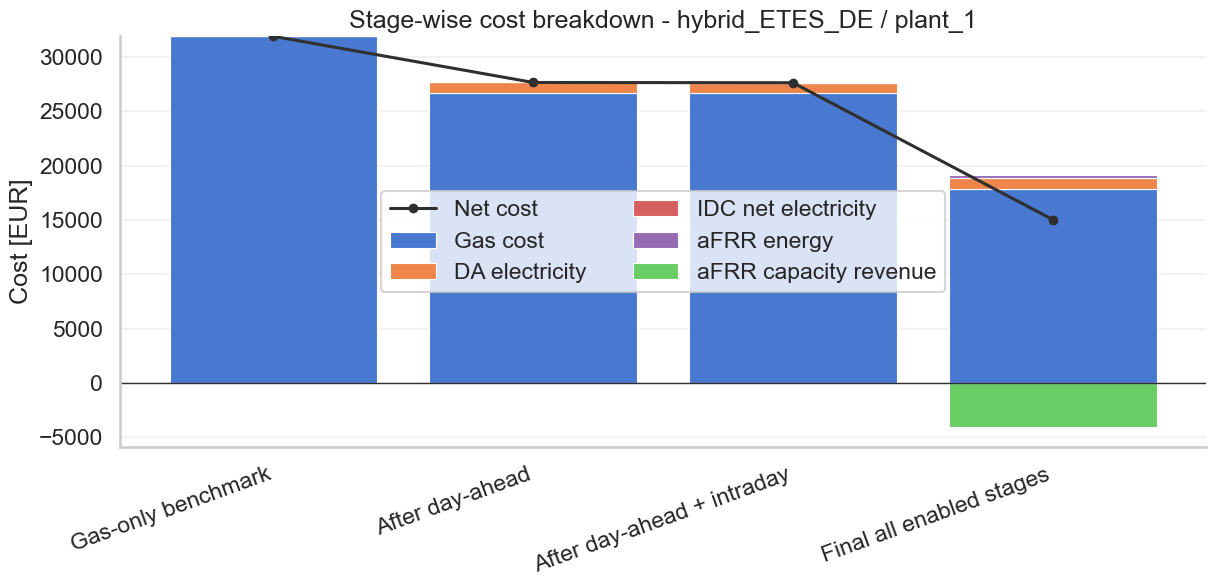

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("muted")


def _stack_bar(ax, x, values, positive_bottom, negative_bottom, label, color):
    """Add a stacked bar component while handling positive and negative costs."""
    values = values.astype(float)
    bottoms = positive_bottom.where(values >= 0.0, negative_bottom)
    ax.bar(
        x,
        values,
        bottom=bottoms,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.8,
    )
    positive_bottom += values.where(values >= 0.0, 0.0)
    negative_bottom += values.where(values < 0.0, 0.0)
    return positive_bottom, negative_bottom


def plot_stage_cost_breakdown(stage_table: pd.DataFrame) -> None:
    """Plot stacked stage costs for each selected scenario and plant."""
    palette = sns.color_palette("muted", 5)
    cost_components = [
        ("gas_cost_EUR", "Gas cost", palette[0]),
        ("DA_electricity_cost_EUR", "DA electricity", palette[1]),
        ("IDC_net_electricity_cost_EUR", "IDC net electricity", palette[3]),
        ("afrr_energy_cost_EUR", "aFRR energy", palette[4]),
        ("capacity_revenue_negative_EUR", "aFRR capacity revenue", palette[2]),
    ]

    for (scenario, plant), frame in stage_table.groupby(["scenario", "plant"], sort=True):
        plot_frame = frame.copy()
        plot_frame["stage"] = plot_frame["stage"].astype(str)
        plot_frame["capacity_revenue_negative_EUR"] = -plot_frame["capacity_revenue_EUR"]

        x = range(len(plot_frame))
        positive_bottom = pd.Series(0.0, index=plot_frame.index)
        negative_bottom = pd.Series(0.0, index=plot_frame.index)

        fig, ax = plt.subplots(figsize=(12.5, 6.2))
        for column, label, color in cost_components:
            positive_bottom, negative_bottom = _stack_bar(
                ax,
                x,
                plot_frame[column],
                positive_bottom,
                negative_bottom,
                label,
                color,
            )

        ax.plot(
            x,
            plot_frame["net_cost_EUR"],
            color="#2F2F2F",
            marker="o",
            markersize=6,
            linewidth=2.2,
            label="Net cost",
        )

        ax.axhline(0, color="#2F2F2F", linewidth=1.0)
        ax.set_title(f"Stage-wise cost breakdown - {scenario} / {plant}")
        ax.set_ylabel("Cost [EUR]")
        ax.set_xticks(list(x))
        ax.set_xticklabels(plot_frame["stage"], rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.25)
        ax.grid(axis="x", visible=False)
        ax.legend(loc="best", ncols=2, frameon=True)
        sns.despine(ax=ax)
        fig.tight_layout()
        plt.show()


plot_stage_cost_breakdown(stage_cost_table)